<center><img src="img/logo_hse.png" width="1000"></center>

<h1><center>Генеративные модели в машинном обучении, МОВС, ФКН ВШЭ</center></h1>
<h2><center>Домашнее задание 3: Диффузия, потоки</center></h2>

# Введение

До заголовка "Диффузионные модели" все по-старому. Только Задания 1-2 теперь неоцениваемые, ведь вы их уже делали

## MAGIC – Major Atmospheric Gamma Imaging Cherenkov Telescope

MAGIC (Major Atmospheric Gamma Imaging Cherenkov) - это система, состоящая из двух черенковских телескопов диаметром 17 м. Они предназначены для наблюдения гамма-лучей от галактических и внегалактических источников в диапазоне очень высоких энергий (от 30 ГэВ до 100 ТэВ).

MAGIC позволил открыть и исследовать новые классы источников гамма-излучения, таких как, например, пульсары и гамма-всплески (GRB).

<center><img src="img/magic1.jpg" width="1000"></center>

Источник: https://magic.mpp.mpg.de/

Youtube video: https://youtu.be/mjcDSR2vSU8

    Ок, давайте зафиксируем. Какой-то крутой телескоп позволяет открыть новые виды излучения. Идем дальше.

## Частицы из космоса

Космические частицы, $\gamma$-кванты (фотоны) и адроны (протоны), взаимодействуют с атмосферой и порождают ливни вторичных частиц. Двигаясь с околосветовой скоростью, эти частицы излучают Черенковское излучение. Телескопы фотографируют это излучение.

    По фотографиям можно определить тип частицы из космоса: фотон или протон. Знакомая формулировка задачи, не правда ли?

<center><img src="img/shower.jpg" width="500"></center>

## Фотографии

Задача атмосферного черенковского телескопа - получить изображение ливня путем измерения черенковского света от частиц ливня. Это изображение представляет собой геометрическую проекцию ливня на детектор. Для анализа этих изображений были введены параметры изображения или так называемые параметры Хилласа. Ниже пример такой фотографии.

<center><img src="img/geo.jpg" width="400"></center>

    Итак, каждая фотография описывается набором параметров, которые за нас считает телесоп. А что там с двумя видами частиц?

## Фотоны vs адронов

Изображения для $\gamma$-квантов (фотонов) и адронов (протонов) отличаются по форме кластеров. Астрономы используют модели машинного обучения для классификации этих изображений. Получение каждого такого изображения - дорогое удовольствие!


<center><img src="img/gamma_p.png" width="600"></center>

Для обучения моделей ученые искусственно генерируют такие изображения для каждого типа частиц с помощью сложных физических симуляторов.

    Итак, давайте сэкономим денег для ученых и сгенерируем хороших фотографий разных частиц. Используем для этого GAN и диффузионные модели!

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Данные

Будем использовать данные телескопа MAGIC из UCI репозитория https://archive.ics.uci.edu/ml/datasets/MAGIC+Gamma+Telescope. Каждый объект в данных - параметры одного изображения кластера и метка этого кластера (фотон или адрон):


0. Length: major axis of ellipse [mm]
1. Width: minor axis of ellipse [mm]
2. Size: 10-log of sum of content of all pixels [in #phot]
3. Conc: ratio of sum of two highest pixels over fSize [ratio]
4. Conc1: ratio of highest pixel over fSize [ratio]
5. Asym: distance from highest pixel to center, projected onto major axis [mm]
6. M3Long: 3rd root of third moment along major axis [mm]
7. M3Trans: 3rd root of third moment along minor axis [mm]
8. Alpha: angle of major axis with vector to origin [deg]
9. Dist: distance from origin to center of ellipse [mm]
10. class: g,h # gamma (signal), hadron (background)

In [3]:
# read data
names = np.array(
    [
        "Length",
        "Width",
        "Size",
        "Conc",
        "Conc1",
        "Asym",
        "M3Long",
        "M3Trans",
        "Alpha",
        "Dist",
        "class",
    ]
)
data = pd.read_csv("data/magic04.data", header=None)
data.columns = names
print(data.shape)
data.head()

(19020, 11)


,Length,Width,Size,Conc,Conc1,Asym,M3Long,M3Trans,Alpha,Dist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


# Постановка задачи

Ваша задача заключается в том, чтобы с помощью генеративно-состязательных сетей научиться генерировать параметры кластеров на изображениях телескопа для каждого типа частиц (фотона или адрона):

- $X$ - матрица реальных объектов, которые нужно начиться генерировать;
- $y$ - метки классов, которые будем использовать как условие при генерации.

In [4]:
# параметры кластеров на изображениях
X = data[names[:-1]].values
X = np.abs(X)

# метки классов
labels = data[names[-1]].values
y = np.ones((len(labels), 1))
y[labels == "h"] = 0

In [5]:
# примеры
X[:2]

array([[2.87967e+01, 1.60021e+01, 2.64490e+00, 3.91800e-01, 1.98200e-01,
        2.77004e+01, 2.20110e+01, 8.20270e+00, 4.00920e+01, 8.18828e+01],
       [3.16036e+01, 1.17235e+01, 2.51850e+00, 5.30300e-01, 3.77300e-01,
        2.62722e+01, 2.38238e+01, 9.95740e+00, 6.36090e+00, 2.05261e+02]])

In [6]:
# примеры
y[:10]

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.]])

In [7]:
# все возможные значения
np.unique(y)

array([0., 1.])

# Визуализация данных

Каждое изображение описывается 10 параметрами. Давайте построим распределения значений каждого параметра для каждого типа частиц.

In [8]:
def plot_hists(X1, X2, names, label1, label2, bins=np.linspace(-3, 3, 61)):
    plt.figure(figsize=(5 * 4, 5 * 2))
    for i in range(X1.shape[1]):
        plt.subplot(3, 4, i + 1)
        plt.grid()
        plt.hist(X1[:, i], bins=bins, alpha=0.3, label=label1, color="C4")
        plt.hist(X2[:, i], bins=bins, alpha=0.3, label=label2, color="C0")
        plt.xlabel(names[i], size=14)
        plt.legend(loc="best")
    plt.tight_layout()

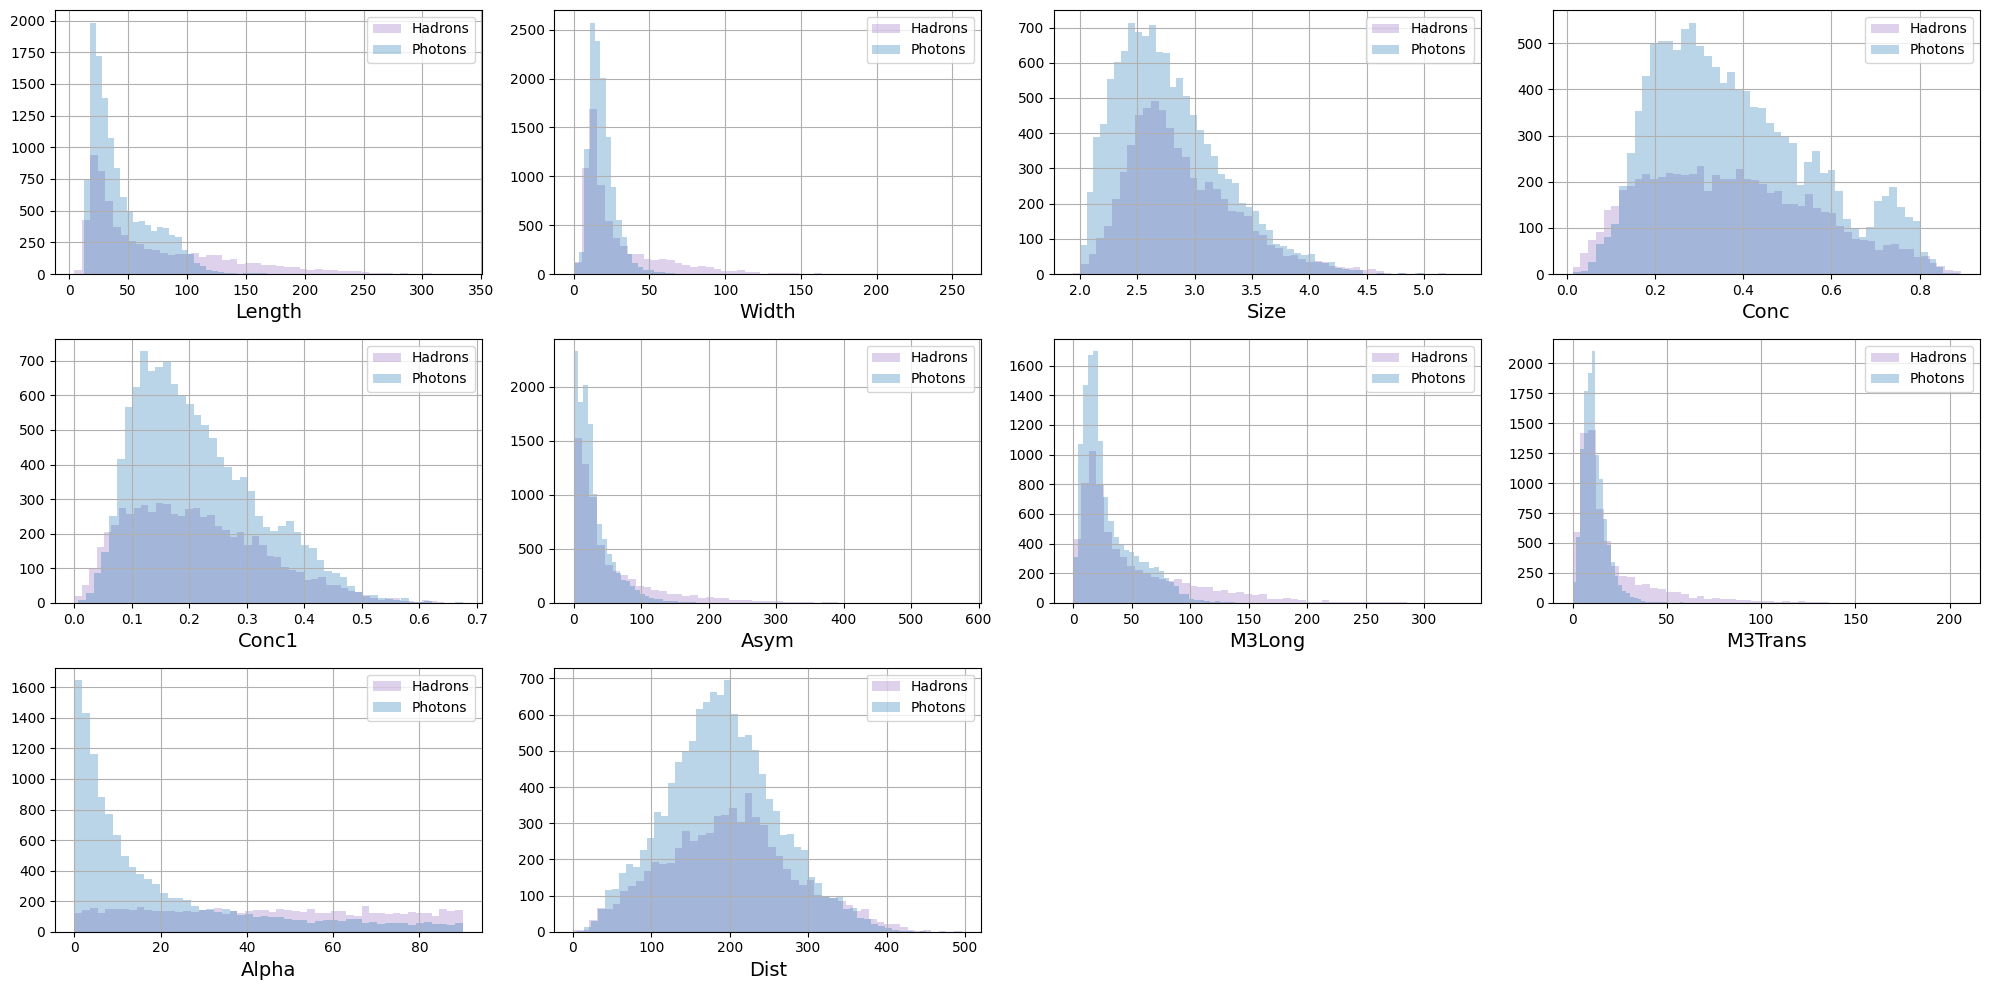

In [9]:
plot_hists(
    X[y[:, 0] == 0], X[y[:, 0] == 1], names, label1="Hadrons", label2="Photons", bins=50
)

# Предобработка данных

Из графика видим, что распределения для многих признаков имеют тяжелые хвосты. Это делает обучение генеративных моделей тяжелее. Поэтому нужно как-то преобразовать данные, чтобы убрать эти тяжелые хвосты.

# Обучающая и тестовая выборки

In [10]:
from sklearn.model_selection import train_test_split

# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify = y, test_size=0.5, shuffle = True, random_state = 11
)

## Задание 1 (0 баллов)

Проиллюстрируйте распределение y внутри train и test выборки.

In [11]:
df_y = pd.DataFrame({
    'train': np.squeeze(y_train),
    'test': np.squeeze(y_test)
})

df_y

,train,test
0,0.0,0.0
1,0.0,0.0
2,0.0,1.0
3,1.0,0.0
4,0.0,1.0
...,...,...
9505,1.0,1.0
9506,1.0,0.0
9507,1.0,1.0
9508,1.0,1.0


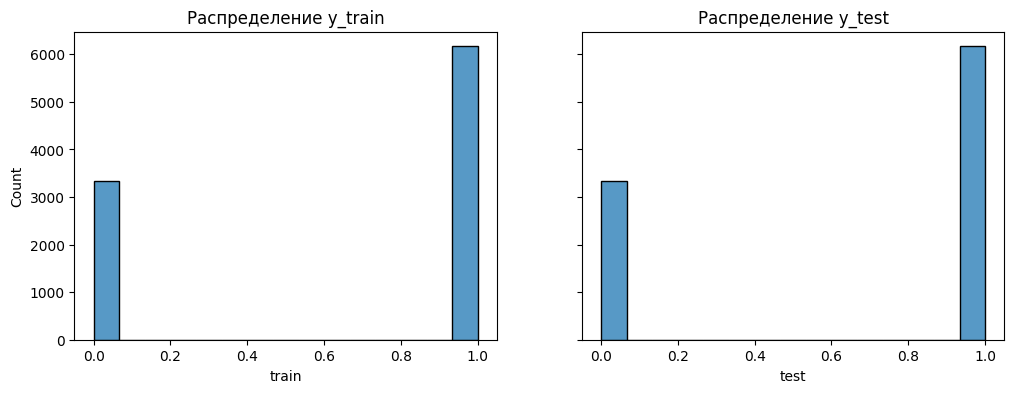

In [ ]:
# your code below
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.histplot(data=df_y, x="train", ax=axes[0])
axes[0].set_title("Распределение y_train")

sns.histplot(data=df_y, x="test", ax=axes[1])
axes[1].set_title("Распределение y_test")

plt.show()

## Задание 2 (0 баллов)

Используя функцию `sklearn.preprocessing.QuantileTransformer` трансформируйте входные данные `X_train` и `X_test`. Это преобразование делает так, чтобы распределение каждого параметра было нормальным. Описание функции доступно по [ссылке](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.QuantileTransformer.html). Используйте значение параметра `output_distribution='normal'`.

In [13]:
### YOUR CODE IS HERE ######
from sklearn.preprocessing import QuantileTransformer

qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_train = qt.fit_transform(X_train)
X_test = qt.fit_transform(X_test)
### THE END OF YOUR CODE ###

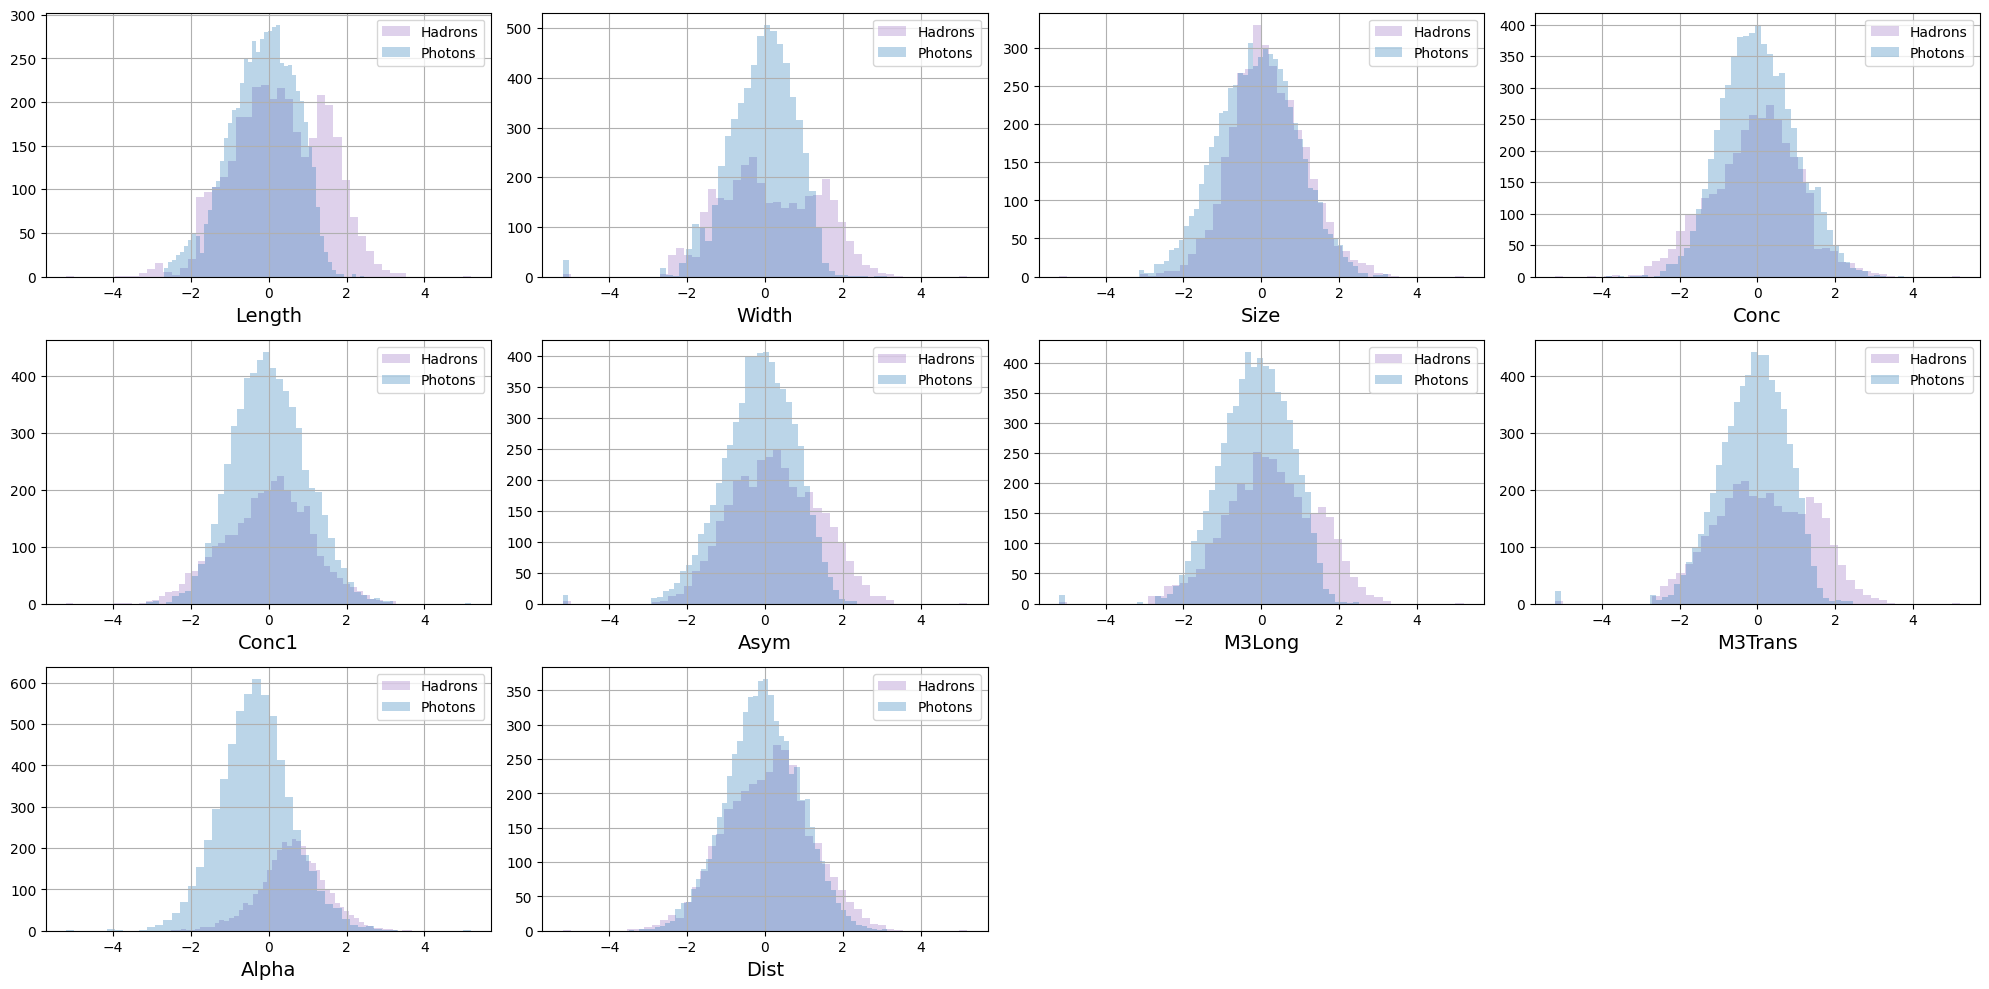

In [14]:
plot_hists(
    X_train[y_train[:, 0] == 0],
    X_train[y_train[:, 0] == 1],
    names,
    label1="Hadrons",
    label2="Photons",
    bins=50,
)

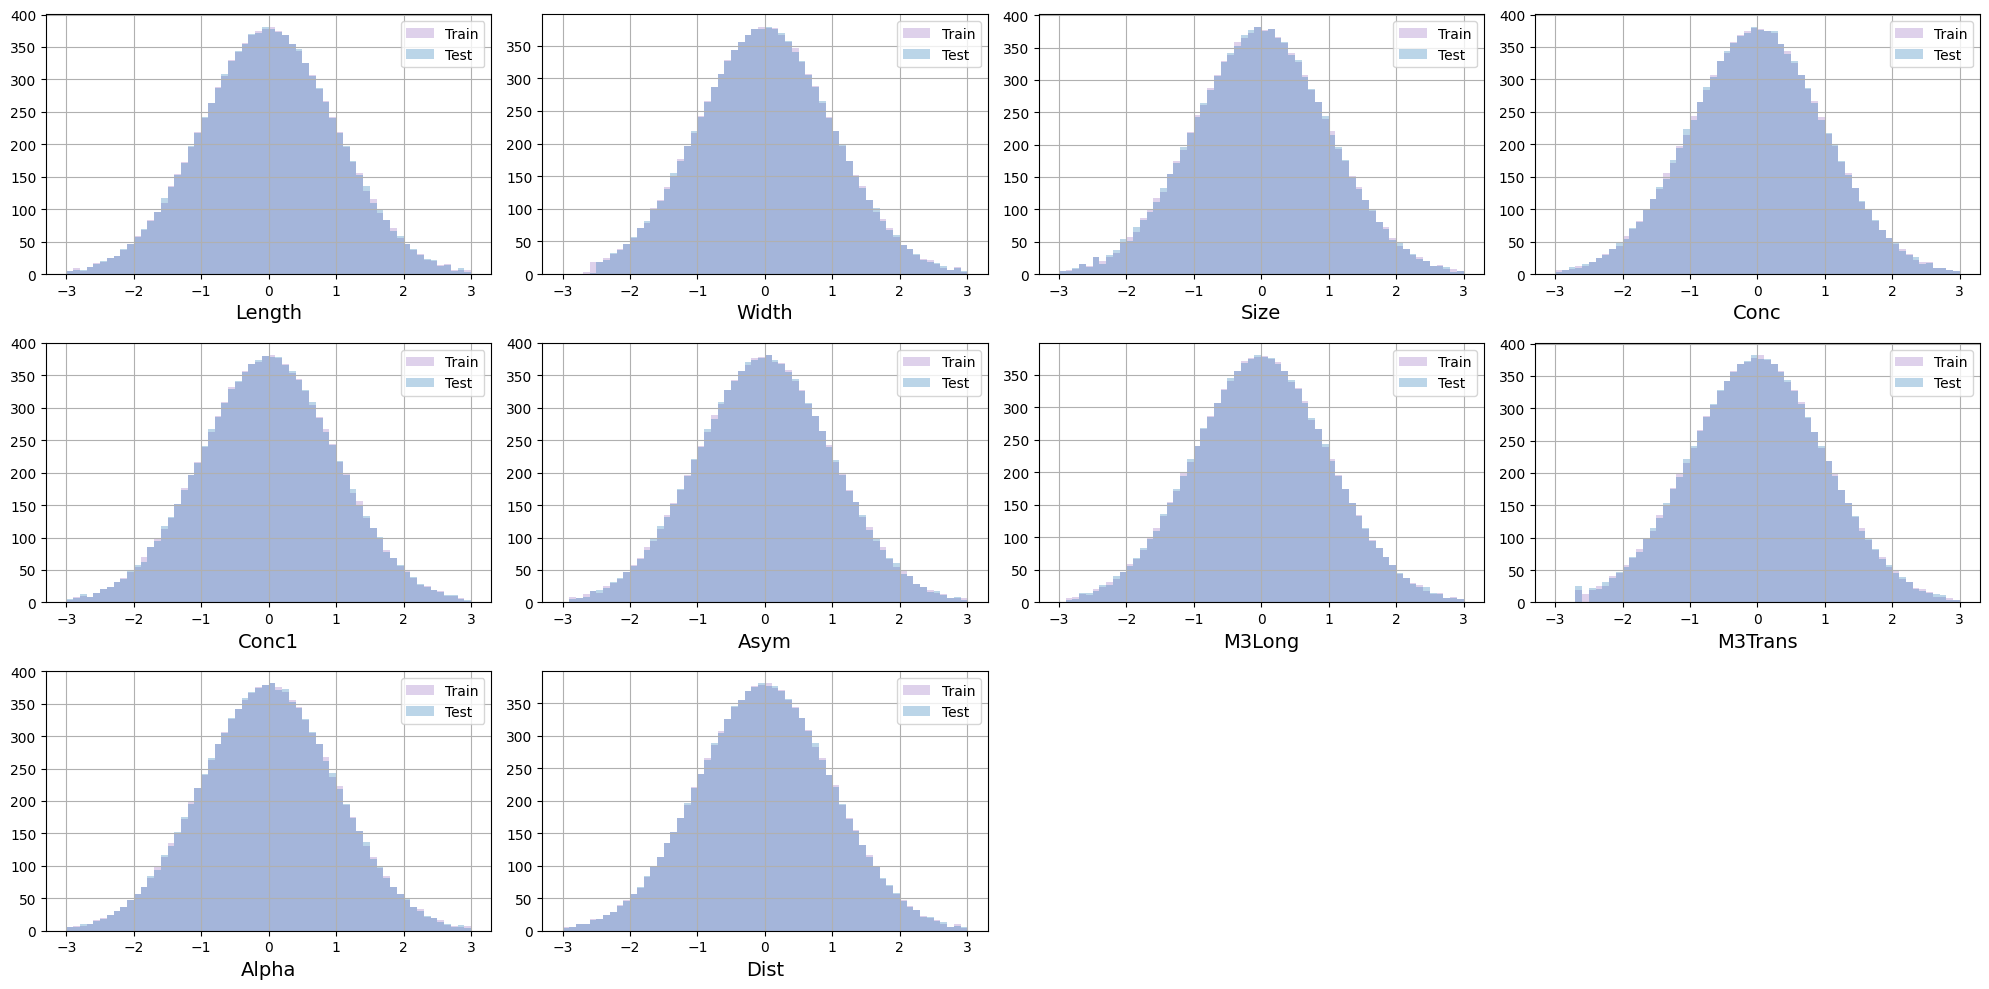

In [15]:
plot_hists(X_train, X_test, names, label1="Train", label2="Test")

# Диффузионные модели (4 балла)

Проведем, по большому счету, такой же эксперимент, как в ДЗ-2, с диффузионной моделью.

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset

DEVICE = 'mps' # torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Задание 3 (0.5 балла)

Реализуйте фукнцию из семинара для зашумления данных, адаптировав ее под наш тип данных.

In [17]:
def corrupt(x, amount):
    ### YOUR CODE IS HERE ######
    noise = torch.rand_like(x)
    amount = amount.view(-1,1) # .view(-1,1,1,1)
    x = x * (1 - amount) + noise * amount
    ### THE END OF YOUR CODE ###
    return x

Добавим sсheduler, он пригодится вам при обучении модели.

*Советуем вниматиельно почитать доку по шедулеру.*

In [18]:
from diffusers import DDPMScheduler

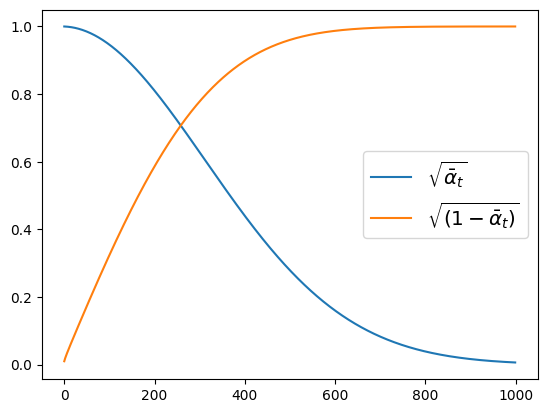

In [19]:
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$")
plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{(1 - \bar{\alpha}_t)}$")
plt.legend(fontsize="x-large")

## Задание 4 (0.5 балла)

Реализуйте нейронную сеть. В качетсве архитектуры можете взять модель генератора. В процессе экспериментов попробуйте изменять архитектуру модели для улучшения качества сгенерированных объектов (Кстати, как вы будете качество измерять?).

- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Полносвязный слой со 100 нейронами;
- Слой батч-нормализации;
- ReLU функцию активации;
- Выходной слой.

In [46]:
class DiffusionGenerator(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super(DiffusionGenerator, self).__init__()

        ### YOUR CODE IS HERE ######
        model = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, n_outputs)
        )
        self.net = model
        ### THE END OF YOUR CODE ###

    def forward(self, z, y):
        zy = torch.cat((z, y), dim=1)
        return self.net(zy)

## Задание 5 (0.5 балла)

Напишите функцию для генерации нового объекта с помощью обученной модели.

In [40]:
def generate_with_diffusion(model, y, latent_dim, scheduler):
    ### YOUR CODE IS HERE ######
    y_tensor = torch.tensor(y, dtype=torch.float, device=DEVICE)
    # шум для начала
    noise2image = torch.normal(0, 1, (len(y), latent_dim), device=DEVICE)
    
    # цикл шедулера
    for times in scheduler.timesteps:
        with torch.no_grad():
            noise_pred = model(noise2image, y_tensor) # шум для тек шага
        noise2image = scheduler.step(noise_pred, times, noise2image).prev_sample

    X_fake = noise2image.cpu().numpy()
    ### THE END OF YOUR CODE ###
    return X_fake  # numpy

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

def other_agent_score(real_samples, fake_samples, random_state = 42):

    real_samples = np.asarray(real_samples)
    fake_samples = np.asarray(fake_samples)

    X_stack = np.vstack([real_samples, fake_samples])
    y = np.concatenate([
        np.ones(real_samples.shape[0], dtype=int),
        np.zeros(fake_samples.shape[0], dtype=int),
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X_stack,
        y,
        test_size=0.3,
        stratify=y,
        random_state=random_state,
        shuffle=True,
    )

    logreg = LogisticRegression()
    logreg.fit(X_train, y_train)
    logreg_acc = accuracy_score(y_test, logreg.predict(X_test))

    gboost = GradientBoostingClassifier(random_state=random_state)
    gboost.fit(X_train, y_train)
    gboost_acc = accuracy_score(y_test, gboost.predict(X_test))

    # print(f"LogisticRegression accuracy: {logreg_acc:.4f}")
    # print(f"GradientBoosting accuracy: {gboost_acc:.4f}")

    return {"logreg": logreg_acc, "gboost": gboost_acc}


## Задание 6 (2 балла)

Напишите класс обучения диффузионной модели и обучите модель, после чего опишите полученные результаты. В качестве подсказки - опирайтесь на семинар по диффузионным моделям. Вы можете изменять некоторые части кода для вашего удобства, но оставляйте в таком случаи комментарии, пожалуйста.

In [42]:
class DiffusionFitter(object):
    def __init__(
        self,
        model,
        batch_size = 32,
        n_epochs = 10,
        latent_dim = 1,
        lr = 0.0001,
        n_critic=5,
    ):

        self.model = model
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.latent_dim = latent_dim
        self.lr = lr
        self.n_critic = n_critic

        self.opt_gen = torch.optim.RMSprop(self.model.parameters(), lr=self.lr)

        self.model.to(DEVICE)

    def fit(self, X, y):

        # numpy to tensor
        X_real = torch.tensor(X, dtype=torch.float, device=DEVICE)
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

        # tensor to dataset
        dataset_real = TensorDataset(X_real, y_cond)

        # Turn on training
        self.model.train(True)

        self.loss_history = []

        # Fit
        for epoch in range(self.n_epochs):
            loss_epoch = 0
            for i, (real_batch, cond_batch) in enumerate(
                DataLoader(dataset_real, batch_size=self.batch_size, shuffle=True)
            ):

                ### YOUR CODE IS HERE ######
                # шум
                noise = torch.randn_like(real_batch) # N(0,1)
                # шаги
                timesteps = torch.randint(
                    0,
                    noise_scheduler.num_train_timesteps,
                    (real_batch.size(0),),
                    device=DEVICE,
                    dtype=torch.long,
                )
                # добавление шума
                noisy_batch = noise_scheduler.add_noise(real_batch, noise, timesteps)

                self.opt_gen.zero_grad()

                noise_pred = self.model(noisy_batch, cond_batch)
                loss = F.mse_loss(noise_pred, noise)
                loss.backward()
                self.opt_gen.step()

                loss_epoch += loss.item()
                ### THE END OF YOUR CODE ###

            # caiculate and store loss after an epoch

            self.loss_history.append(loss_epoch)

            # Создайте выборку из 1000 объектов из X_train и 1000 сгенерированных объектов
            # И запустите работу фукнции other_agent_score

            ### YOUR CODE IS HERE ######
            sample_size = 1000
            idx = torch.randperm(X_real.shape[0], device=DEVICE)[:sample_size]

            real_subset = X_real[idx].detach().cpu().numpy()
            cond_subset = y_cond[idx].detach().cpu().numpy()
            fake_subset = generate_with_diffusion(self.model, cond_subset, self.latent_dim, noise_scheduler)
            # 
            score = other_agent_score(real_subset, fake_subset)

            print(f"эпоха {epoch + 1}/{self.n_epochs}; loss: {loss_epoch:.2f}")
            print(f"other agent score: {score}")
            ### THE END OF YOUR CODE ###

        # Turn off training
        self.model.train(False)

In [47]:
%%time
latent_dim = 10
model = DiffusionGenerator(n_inputs=latent_dim + y.shape[1], n_outputs=X_train.shape[1])

diffusionFitter = DiffusionFitter(
    model,
    batch_size=50,
    n_epochs=100,
    latent_dim=latent_dim,
    lr=0.0001,
    n_critic=5,
)
diffusionFitter.fit(X_train, y_train)

эпоха 1/100; loss: 108.13
other agent score: {'logreg': 0.6766666666666666, 'gboost': 0.925}


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


эпоха 2/100; loss: 70.21
other agent score: {'logreg': 0.725, 'gboost': 0.9316666666666666}


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


эпоха 3/100; loss: 63.22
other agent score: {'logreg': 0.7183333333333334, 'gboost': 0.94}


...

эпоха 98/100; loss: 49.07
other agent score: {'logreg': 0.88, 'gboost': 0.96}


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


эпоха 99/100; loss: 50.57
other agent score: {'logreg': 0.8783333333333333, 'gboost': 0.9566666666666667}


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


эпоха 100/100; loss: 50.98
other agent score: {'logreg': 0.8, 'gboost': 0.9666666666666667}
CPU times: user 3min 51s, sys: 2min 56s, total: 6min 47s
Wall time: 2min 18s


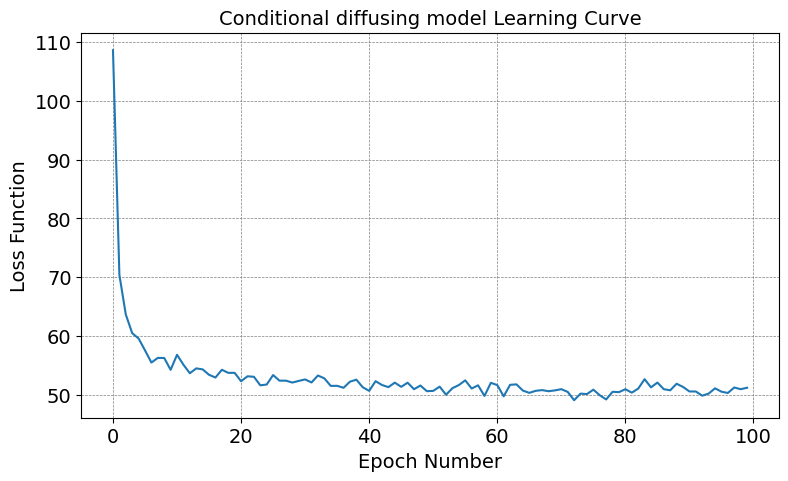

In [37]:
# diffusion learning curve
plt.figure(figsize=(9, 5))
plt.plot(diffusionFitter.loss_history)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("Conditional diffusing model Learning Curve", size=14)
plt.grid(visible=True, linestyle="--", linewidth=0.5, color="0.5")
plt.show()

## Задание 7 (0.5 балла)
По аналогии с прошлым экспериментом (из ДЗ-2) с GAN моделью сгенерируйте выборку фейковых объектов, равную размеру тестовой выборки, и обучите градиентный бустинг. Обучите модель отличать реальные объекты от фейковых, после чего расчитайте метрики ROC-AUC и accuracy score. Какие получились результаты? Как вы их оцениваете? А в сравнении с сWGAN моделью?

In [38]:
from sklearn.metrics import roc_auc_score

# ген
X_fake_test = generate_with_diffusion(
    diffusionFitter.model,
    y_test,
    diffusionFitter.latent_dim,
    noise_scheduler,
)

# real + fake
X_mix = np.vstack([X_test, X_fake_test])
# 1 - real
y_mix = np.concatenate([
    np.ones(len(X_test), dtype=int),
    np.zeros(len(X_fake_test), dtype=int),
])

# split
X_mix_train, X_mix_test, y_mix_train, y_mix_test = train_test_split(
    X_mix,
    y_mix,
    test_size=0.3,
    stratify=y_mix,
    random_state=42,
)

# град бустинг
adv_clf = GradientBoostingClassifier(random_state=42)
adv_clf.fit(X_mix_train, y_mix_train)

# пред
y_mix_pred = adv_clf.predict(X_mix_test)
y_mix_prob = adv_clf.predict_proba(X_mix_test)[:, 1]

roc_auc = roc_auc_score(y_mix_test, y_mix_prob)
accuracy = accuracy_score(y_mix_test, y_mix_pred)

print(f"GB ROC AUC: {roc_auc:.4f}")
print(f"GB accuracy: {accuracy:.4f}")


GB ROC AUC: 0.9998
GB accuracy: 0.9946


Лучший результат был у VAE (0.73) - тут результат значительно хуже (0.9998)

# Потоки (4 балла)

## Задание 8 (1.5 балла)

Диффузия показала себя как достойный конкурент GAN модели. Так как данных не много, обучали не долго, задача не сложная - отличия от GAN не так заметны, но все равно достойные.

Для Diffusion получили ROC AUC около 0.73 (меньше лучше). Попробуем обучить RealNVP для решения этой задачи.

**Дополните базовый класс для нормализационного необходимым.**

<center><img src="img/mem1.jpg" width="500"></center>

<center><img src="img/mem2.jpg" width="500"></center>

In [27]:
trainloader = torch.utils.data.DataLoader(X_train, batch_size=64, shuffle=True)

In [28]:
# Main class for NormFlow
class NormalizingFlow(nn.Module):

    def __init__(self, layers, prior):
        super(NormalizingFlow, self).__init__()

        # your code below
        self.layers = nn.ModuleList(layers)
        self.prior = prior

    def log_prob(self, x):
        log_likelihood = None

        # посл-ность преобразований
        for layer in self.layers:
            x, change = layer.f(x)
            if log_likelihood is not None:
                log_likelihood = log_likelihood + change
            else:
                log_likelihood = change

        log_likelihood = log_likelihood + self.prior.log_prob(x)

        return log_likelihood.mean()

    def sample(self, num_samples):
        x = self.prior.sample((num_samples, ))

        for layer in self.layers[::-1]:
            x = layer.g(x)

        return x

## Задание 9 (2 балла)

Реализуйте нейронную сеть RealNVP. Возьмите для прямого и обратного преобразования нейронную сеть (функцию) со следующими параметрами:

- Полносвязный слой со 100 нейронами;
- ReLU функцию активации;
- Выходной слой.

In [ ]:
class RealNVP(nn.Module):
    def __init__(self, var_size, mask, hidden=100):
        super(RealNVP, self).__init__()
        self.mask = mask  # вам это может не понадобиться. Восприниматйте как подсказку
        self.var_size = var_size

        nn_seq = nn.Sequential(
            nn.Linear(var_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, var_size)
        )

        self.nn_t = nn_seq
        self.nn_s = nn_seq

    def f(self, x):
        x_masked = x * self.mask
        # параметры аффинного преобразования
        t = self.nn_t(x_masked)
        s = torch.tanh(self.nn_s(x_masked))

        # преобразование свободных координат
        x_processed = (1 - self.mask) * (x * torch.exp(s) + t)
        new_x = x_masked + x_processed

        # сумма s по измененным координатам
        log_det = ((1 - self.mask) * s).sum(dim=1)
        
        return new_x, log_det

    def g(self, x):
        x_masked = x * self.mask
        t = self.nn_t(x_masked)
        s = torch.tanh(self.nn_s(x_masked))

        new_x = x_masked + (1 - self.mask) * ((x - t) * torch.exp(-s))
        return new_x

In [30]:
def train_nf(tr_dataloader, nf, opt, num_epochs):
    nf.train()
    loss_trace = []

    iter_i = 0

    for epoch_i in range(num_epochs):
        print(f'Epoch {epoch_i + 1}')
        for batch in tr_dataloader:

            x = batch.float()

            opt.zero_grad()

            loss = -nf.log_prob(x)
            loss.backward()

            opt.step()

            loss_trace.append((iter_i, loss.item()))

            iter_i += 1

In [31]:
prior = torch.distributions.MultivariateNormal(torch.zeros(10), torch.eye(10))

layers = []
for i in range(4):
    layers.append(RealNVP(var_size=10, mask=((torch.arange(10) + i) % 2)))

nf = NormalizingFlow(layers=layers,
                    prior=prior)

opt = torch.optim.Adam(nf.parameters(), lr=1e-3)

In [32]:
train_nf(trainloader, nf, opt, num_epochs=10)

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10


## Задание 10 (0.5 балла)

По аналогии с прошлым экспериментом с диффузией сгенерируйте выборку фейковых объектов, равную размеру тестовой выборки, и обучите градиентный бустинг. Обучите модель отличать реальные объекты от фейковых, после чего расчитайте метрики ROC-AUC и accuracy score. Какие получились результаты? Как вы их оцениваете? А в сравнении с остальными моделями?

In [33]:
# ген
nf.eval()
with torch.no_grad():
    X_fake_nf = nf.sample(len(X_test)).cpu().numpy()

# real + fake
X_nf_mix = np.vstack([X_test, X_fake_nf])
y_nf_mix = np.concatenate([
    np.ones(len(X_test), dtype=int),
    np.zeros(len(X_fake_nf), dtype=int),
])

# split
X_nf_train, X_nf_test, y_nf_train, y_nf_test = train_test_split(
    X_nf_mix,
    y_nf_mix,
    test_size=0.3,
    stratify=y_nf_mix,
    random_state=42,
)

nf_clf = GradientBoostingClassifier(random_state=42)
nf_clf.fit(X_nf_train, y_nf_train)

y_nf_pred = nf_clf.predict(X_nf_test)
y_nf_proba = nf_clf.predict_proba(X_nf_test)[:, 1]

nf_roc_auc = roc_auc_score(y_nf_test, y_nf_proba)
nf_accuracy = accuracy_score(y_nf_test, y_nf_pred)

print(f"nf GB roc auc: {nf_roc_auc:.4f}")
print(f"nd GB accuracy: {nf_accuracy:.4f}")


nf GB roc auc: 0.8994
nd GB accuracy: 0.8100


Здесь результат лучше, чем у дифузии, но все еще не так хорош, как у VAE. Но в целом у всех их троих результат не супер

# Улучшения (1+ балл)

Попробуйте настроить параметры обучения какой-нибудь модели или еще как-нибудь их улучшить, чтобы получить как можно меньший ROC AUC. Что получилось? Какая модель лучше?

Ставим 0.1 балл за каждую сотую скора сверх (сниз) ROC-AUC=0.65 невключительно. Т.е. за 0.65 получаете 0, за 0.649 -- 0.1, 0.639 -- 0.2, 0.609 -- 0.5, 0.559 -- 1

# (*) Аналитика (1 балл)

***Убедительно* подвтердите или опровергните гипотезу "Синтетические данные НЕ помогают лучше классифицировать частицы из исходного датасета."**

Здесь от вас ожидается что-то в духе аналитической записки. Приветствуются графики и прочие "умные вещи". На максимальный балл это весьма объемное задание.